# Prédiction des réadmissions hospitalières à 30 jours

**Mémoire Master 2 — Chef de Projet en Intelligence Artificielle — Eugenia School**

Cas d'application : Ramsay Santé

---

## Objectif

Développer et évaluer un modèle de classification supervisée capable d'identifier,
au moment de la sortie d'hospitalisation, les patients présentant un risque élevé
de réadmission dans les 30 jours.

## Dataset

*Diabetes 130-US Hospitals for years 1999-2008* — UCI Machine Learning Repository / Kaggle

- ~101 766 séjours hospitaliers
- 50 variables (démographie, admission, examens, médicaments, diagnostics)
- Variable cible : `readmitted` ∈ {`<30`, `>30`, `NO`}

## Démarche

| Section | Contenu |
|---|---|
| 1 | Chargement et première exploration |
| 2 | Analyse exploratoire (EDA) |
| 3 | Nettoyage et filtrage de la cohorte |
| 4 | Feature engineering |
| 5 | Préparation finale (encodage, split, standardisation) |
| 6 | Benchmark d'algorithmes et traitement du déséquilibre |
| 7 | Évaluation et optimisation du seuil de décision |
| 8 | Interprétabilité par SHAP |
| 9 | Synthèse et export des résultats |


---
## 0. Configuration de l'environnement

Si certaines librairies manquent, décommenter et exécuter la cellule d'installation.

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost shap imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\ypaubert\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, f1_score, recall_score, precision_score
)

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style des graphiques
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

print('Environnement prêt.')

Environnement prêt.


---
## 1. Chargement et première exploration

Le fichier `diabetic_data.csv` doit être placé dans le même dossier que ce notebook
(ou adapter le chemin ci-dessous).

Le dataset est téléchargeable sur :
- Kaggle : *Diabetes 130-US hospitals for years 1999-2008*
- UCI : https://archive.ics.uci.edu/dataset/296/

> **Piège de lecture à connaître.**
> Les colonnes `max_glu_serum` et `A1Cresult` contiennent la modalité `None`, qui
> signifie « examen non réalisé » — une information cliniquement utile, pas une
> valeur manquante. Or pandas convertit automatiquement la chaîne `None` en `NaN`.
>
> On désactive donc la conversion automatique (`keep_default_na=False`) et on gère
> les manquants manuellement. Sans cette précaution, on détruirait une variable
> informative et on fausserait le diagnostic de complétude.

In [ ]:
CHEMIN_DATA = 'diabetic_data.csv'   # <-- adapter si nécessaire

# keep_default_na=False : empêche pandas de convertir 'None' en NaN
df = pd.read_csv(CHEMIN_DATA, keep_default_na=False, na_values=[])

print(f"Dimensions du jeu de données : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

# Vérification : 'None' doit bien apparaître comme une modalité
print("\nModalités de A1Cresult :", df['A1Cresult'].unique())
print("Modalités de max_glu_serum :", df['max_glu_serum'].unique())

df.head()

In [4]:
# Typologie des variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df['patient_nbr'].nunique()

### 1.1 Détection des valeurs manquantes

Dans ce dataset, les valeurs manquantes ne sont pas codées `NaN` mais par le caractère `?`.
C'est un piège classique : sans ce retraitement, `df.isnull()` renvoie zéro manquant.

In [5]:
# Remplacement du marqueur '?' par NaN
df = df.replace('?', np.nan)

manquants = pd.DataFrame({
    'nb_manquants': df.isnull().sum(),
    'pct_manquants': (df.isnull().sum() / len(df) * 100).round(2)
})
manquants = manquants[manquants['nb_manquants'] > 0].sort_values('pct_manquants', ascending=False)
manquants

,nb_manquants,pct_manquants
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


**Lecture attendue :**

| Variable | Taux de manquants | Décision |
|---|---|---|
| `weight` | ~97 % | Suppression — inexploitable |
| `medical_specialty` | ~49 % | Conservation avec modalité « Inconnu » |
| `payer_code` | ~40 % | Suppression — variable administrative sans valeur clinique |
| `race` | ~2 % | Conservation avec modalité « Inconnu » |

Ce tableau est à reprendre tel quel dans la Partie 2.1 du mémoire.

---
## 2. Analyse exploratoire (EDA)

> **Note méthodologique — deux populations dans ce notebook.**
> L'analyse exploratoire de cette section est conduite au niveau du **séjour**, sur
> l'ensemble des 101 766 séjours bruts (taux de réadmission : 11,16 %, soit 1 positif
> pour 8). La **cohorte de modélisation** est construite en section 3 (exclusions +
> déduplication par patient) : 69 987 patients, taux 8,98 % (1 pour 10).
> Chaque tableau repris dans le mémoire doit préciser sa population.

### 2.1 Distribution de la variable cible

C'est le point le plus important de l'EDA : il détermine toute la stratégie de modélisation.

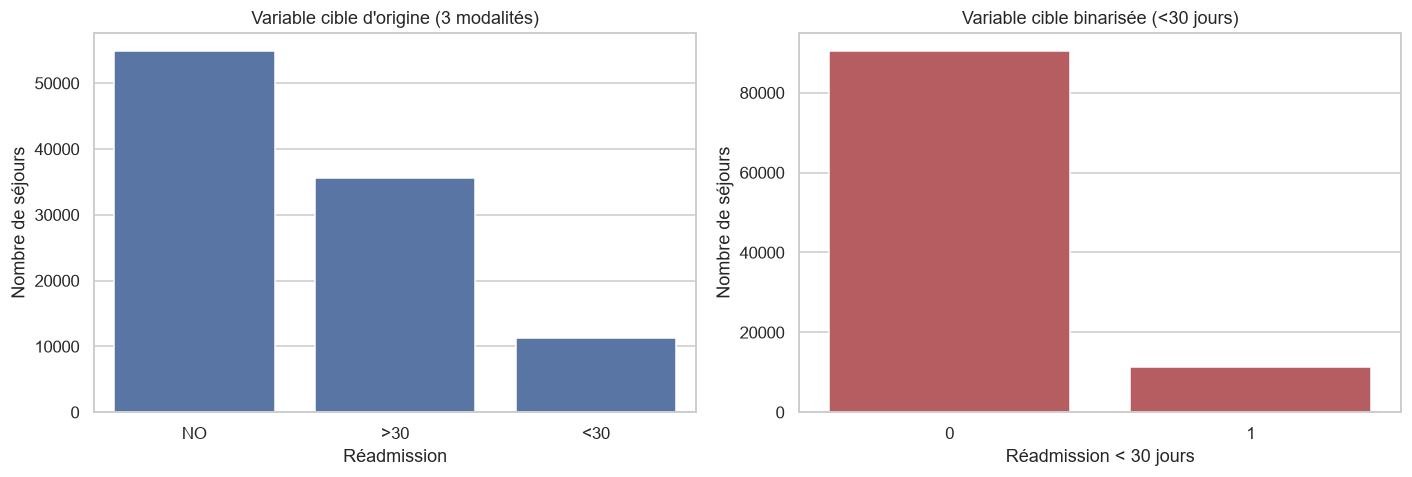

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Taux de réadmission < 30 jours : 11.16%
Ratio de déséquilibre : 1 pour 8.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution des 3 modalités d'origine
ordre = ['NO', '>30', '<30']
sns.countplot(data=df, x='readmitted', order=ordre, ax=axes[0], color='#4C72B0')
axes[0].set_title("Variable cible d'origine (3 modalités)")
axes[0].set_xlabel('Réadmission')
axes[0].set_ylabel('Nombre de séjours')

# Distribution binaire
cible_binaire = (df['readmitted'] == '<30').astype(int)
sns.countplot(x=cible_binaire, ax=axes[1], color='#C44E52')
axes[1].set_title("Variable cible binarisée (<30 jours)")
axes[1].set_xlabel('Réadmission < 30 jours')
axes[1].set_ylabel('Nombre de séjours')

plt.tight_layout()
plt.show()

print(df['readmitted'].value_counts())
print()
taux = cible_binaire.mean()
print(f"Taux de réadmission < 30 jours : {taux:.2%}")
print(f"Ratio de déséquilibre : 1 pour {(1-taux)/taux:.1f}")

> **Point clé pour le mémoire.**
> La classe positive représente environ 11 % des observations. Ce déséquilibre est
> le défi technique central du projet :
> - Un modèle prédisant systématiquement « pas de réadmission » atteindrait ~89 % d'accuracy
>   tout en étant cliniquement inutile.
> - **L'accuracy est donc une métrique trompeuse ici** et ne sera pas retenue comme critère
>   principal. On privilégiera l'AUC-ROC, le rappel et la courbe précision-rappel.

### 2.2 Variables numériques

In [7]:
vars_num = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

df[vars_num].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0


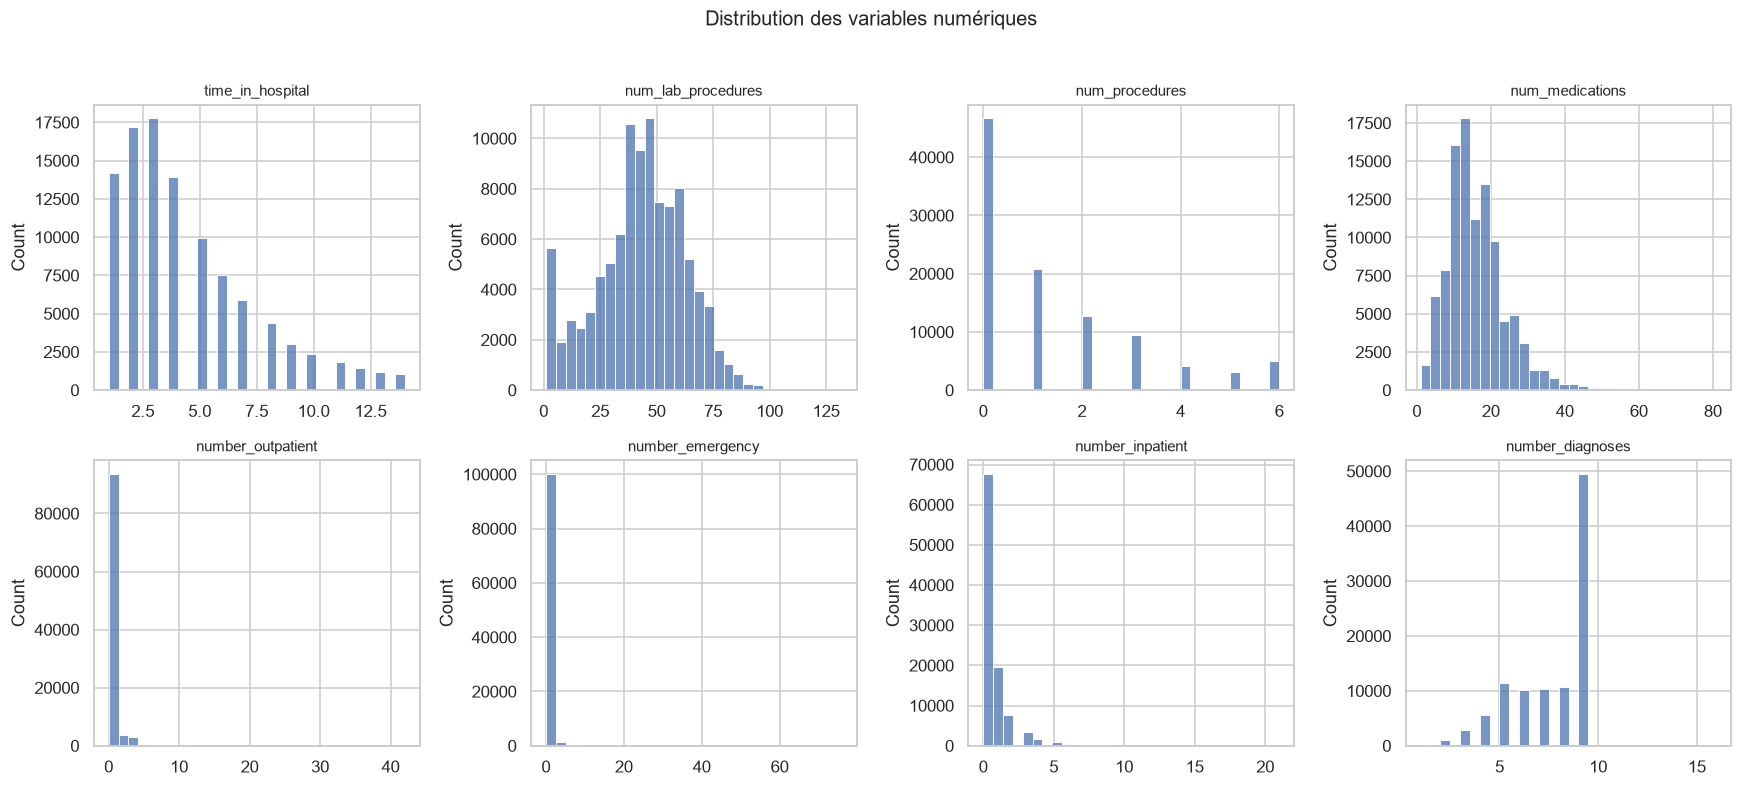

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), vars_num):
    sns.histplot(df[col], bins=30, ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Distribution des variables numériques', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Lien entre variables numériques et réadmission

On compare la moyenne de chaque variable selon que le patient a été réadmis ou non.
Cela donne une première intuition des facteurs de risque, à confirmer ensuite par SHAP.

In [9]:
df_tmp = df.copy()
df_tmp['cible'] = cible_binaire

comparaison = df_tmp.groupby('cible')[vars_num].mean().T
comparaison.columns = ['Non réadmis', 'Réadmis < 30j']
comparaison['écart_%'] = ((comparaison['Réadmis < 30j'] / comparaison['Non réadmis'] - 1) * 100).round(1)
comparaison.round(2).sort_values('écart_%', ascending=False)

,Non réadmis,Réadmis < 30j,écart_%
number_inpatient,0.56,1.22,117.9
number_emergency,0.18,0.36,101.0
number_outpatient,0.36,0.44,21.1
time_in_hospital,4.35,4.77,9.6
num_medications,15.91,16.90,6.2
number_diagnoses,7.39,7.69,4.1
num_lab_procedures,42.95,44.23,3.0
num_procedures,1.35,1.28,-4.9


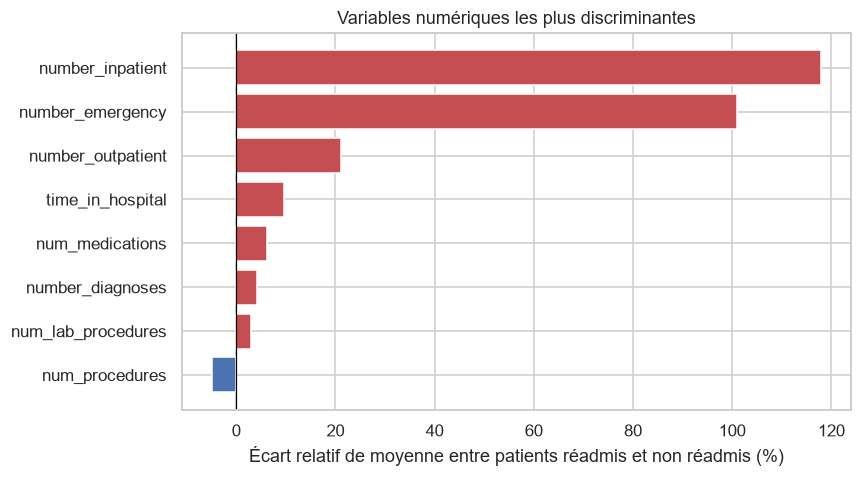

In [10]:
# Visualisation des écarts les plus marqués
ecarts = comparaison['écart_%'].sort_values()
plt.figure(figsize=(8, 4.5))
couleurs = ['#C44E52' if v > 0 else '#4C72B0' for v in ecarts.values]
plt.barh(ecarts.index, ecarts.values, color=couleurs)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Écart relatif de moyenne entre patients réadmis et non réadmis (%)")
plt.title("Variables numériques les plus discriminantes")
plt.tight_layout()
plt.show()

### 2.4 Matrice de corrélation

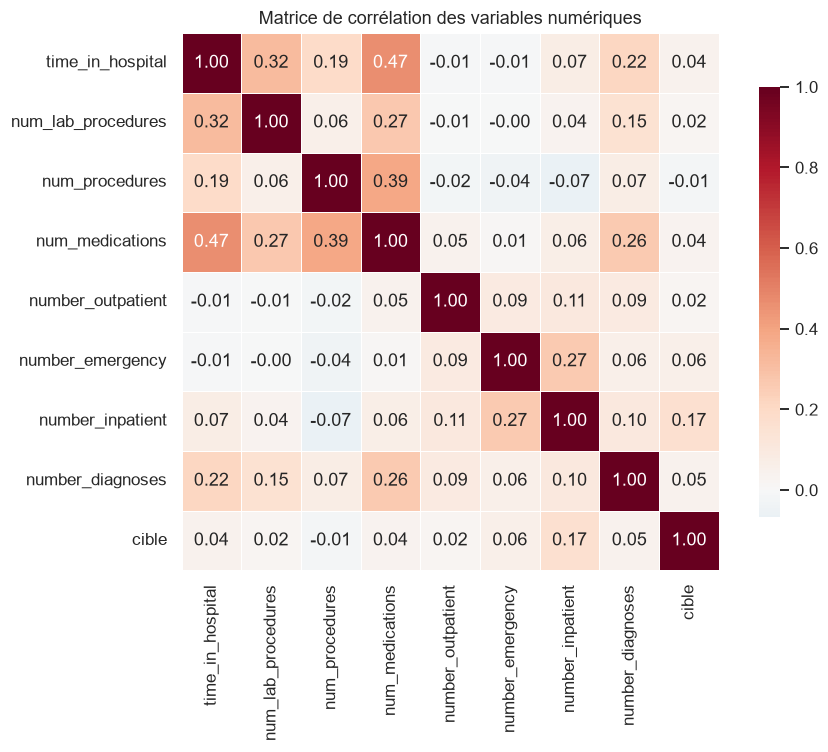

In [11]:
plt.figure(figsize=(9, 7))
corr = df_tmp[vars_num + ['cible']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

### 2.5 Variables catégorielles clés

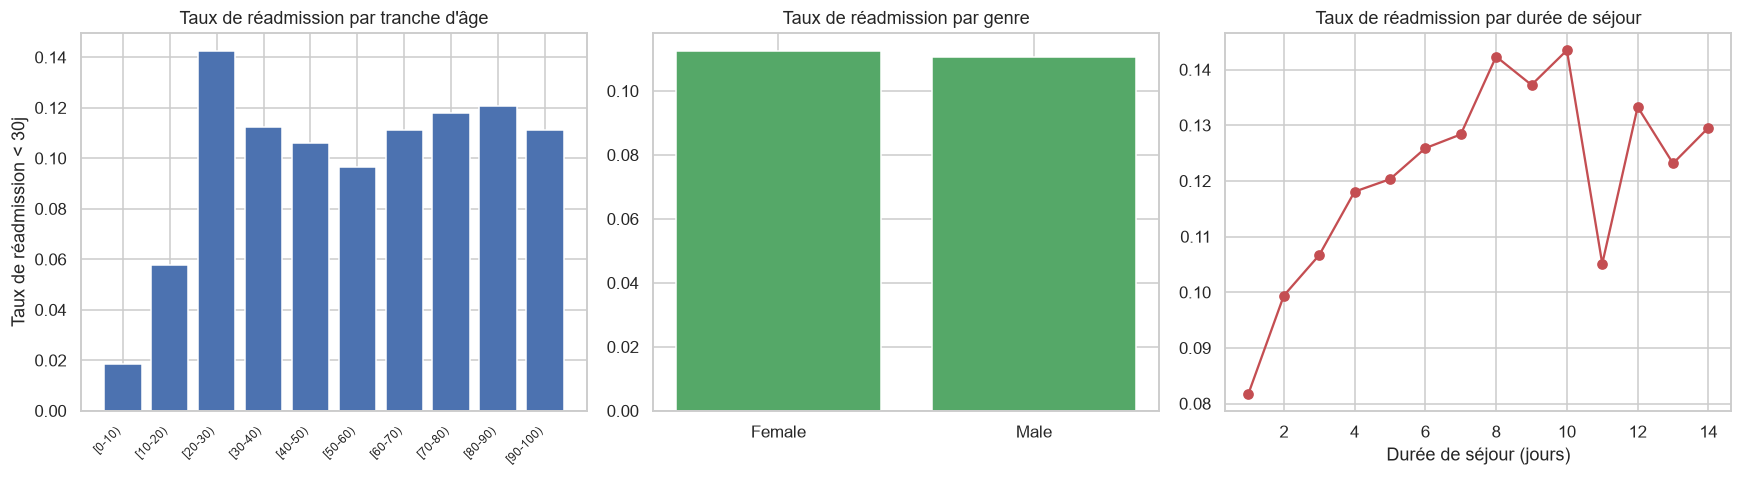

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Âge (tranches)
ordre_age = sorted(df['age'].dropna().unique())
taux_age = df_tmp.groupby('age')['cible'].mean().reindex(ordre_age)
axes[0].bar(range(len(taux_age)), taux_age.values, color='#4C72B0')
axes[0].set_xticks(range(len(taux_age)))
axes[0].set_xticklabels(taux_age.index, rotation=45, ha='right', fontsize=8)
axes[0].set_title("Taux de réadmission par tranche d'âge")
axes[0].set_ylabel('Taux de réadmission < 30j')

# Genre
taux_genre = df_tmp[df_tmp['gender'].isin(['Male', 'Female'])].groupby('gender')['cible'].mean()
axes[1].bar(taux_genre.index, taux_genre.values, color='#55A868')
axes[1].set_title('Taux de réadmission par genre')

# Durée de séjour
taux_duree = df_tmp.groupby('time_in_hospital')['cible'].mean()
axes[2].plot(taux_duree.index, taux_duree.values, marker='o', color='#C44E52')
axes[2].set_title('Taux de réadmission par durée de séjour')
axes[2].set_xlabel('Durée de séjour (jours)')

plt.tight_layout()
plt.show()

---
## 3. Nettoyage et construction de la cohorte


### 3.1 Exclusion des séjours sans issue possible de réadmission

Certaines modalités de `discharge_disposition_id` correspondent à un décès ou à une
orientation en soins palliatifs. Ces patients **ne peuvent pas être réadmis** :
les conserver introduirait un biais en gonflant artificiellement la classe négative.

| Code | Signification |
|---|---|
| 11 | Décès |
| 13 | Sortie en soins palliatifs à domicile |
| 14 | Sortie en soins palliatifs en établissement |
| 19, 20, 21 | Décès (variantes) |

In [ ]:
codes_exclus = [11, 13, 14, 19, 20, 21]

avant = len(df)
df = df[~df['discharge_disposition_id'].isin(codes_exclus)].copy()
print(f"Séjours exclus (décès / soins palliatifs) : {avant - len(df):,}")
print(f"Cohorte restante : {len(df):,} séjours")

### 3.2 Déduplication par patient

Un même patient (`patient_nbr`) peut apparaître plusieurs fois. Conserver tous ses séjours
violerait l'hypothèse d'indépendance des observations et provoquerait une **fuite de données**
entre les jeux d'entraînement et de test.

Convention retenue dans la littérature : ne conserver que le **premier séjour** de chaque patient.

In [ ]:
avant = len(df)
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first').copy()
print(f"Séjours supprimés (doublons patients) : {avant - len(df):,}")
print(f"Cohorte finale : {len(df):,} patients uniques")

### 3.3 Suppression des variables inexploitables

In [ ]:
colonnes_a_supprimer = [
    'weight',          # ~97 % de manquants
    'payer_code',      # variable administrative, ~40 % de manquants
    'encounter_id',    # identifiant technique
    'patient_nbr',     # identifiant patient
    # Médicaments sans variance (toujours 'No' ou quasi)
    'examide', 'citoglipton', 'acetohexamide', 'troglitazone',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone',
]
colonnes_a_supprimer = [c for c in colonnes_a_supprimer if c in df.columns]

df = df.drop(columns=colonnes_a_supprimer)
print(f"Variables supprimées : {len(colonnes_a_supprimer)}")
print(f"Dimensions après nettoyage : {df.shape}")

In [ ]:
# Imputation des catégorielles restantes par une modalité explicite
for col in ['race', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].fillna('Inconnu')

# Suppression des rares genres non renseignés
df = df[df['gender'].isin(['Male', 'Female'])].copy()

print(f"Valeurs manquantes restantes : {df.isnull().sum().sum()}")
print(f"Cohorte finale : {df.shape[0]:,} patients")

---
## 4. Feature engineering

Cette section crée les variables métier qui apportent la valeur ajoutée du projet.
Elles s'inspirent directement des facteurs de risque identifiés dans la littérature
(Pauly et al., 2019 ; index LACE).

### 4.1 Variable cible binaire

In [17]:
df['cible'] = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

print(f"Taux de réadmission < 30 jours dans la cohorte finale : {df['cible'].mean():.2%}")
print(df['cible'].value_counts())

Taux de réadmission < 30 jours dans la cohorte finale : 8.98%
cible
0    63702
1     6285
Name: count, dtype: int64


### 4.2 Conversion de l'âge en variable numérique

L'âge est fourni sous forme de tranches (`[70-80)`). On le convertit en point médian
pour permettre aux modèles d'exploiter la relation ordinale.

In [18]:
def age_vers_numerique(tranche):
    """Convertit une tranche d'âge '[70-80)' en son point médian (75)."""
    bornes = tranche.strip('[)').split('-')
    return (int(bornes[0]) + int(bornes[1])) / 2

df['age_num'] = df['age'].apply(age_vers_numerique)
df[['age', 'age_num']].drop_duplicates().sort_values('age_num')

,age,age_num
0,[0-10),5.0
1,[10-20),15.0
2,[20-30),25.0
3,[30-40),35.0
4,[40-50),45.0
5,[50-60),55.0
11,[60-70),65.0
7,[70-80),75.0
8,[80-90),85.0
9,[90-100),95.0


### 4.3 Historique d'hospitalisation

Variable la plus prédictive dans la littérature : un patient déjà hospitalisé
récemment présente un risque nettement supérieur.

In [19]:
# Nombre total de contacts avec le système de soins sur l'année précédente
df['total_visites_anterieures'] = (
    df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
)

# Indicateur binaire : au moins une hospitalisation antérieure
df['a_deja_ete_hospitalise'] = (df['number_inpatient'] > 0).astype(int)

# Indicateur : passage aux urgences dans l'année
df['passage_urgences_anterieur'] = (df['number_emergency'] > 0).astype(int)

df[['number_outpatient', 'number_emergency', 'number_inpatient',
    'total_visites_anterieures', 'a_deja_ete_hospitalise']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
number_outpatient,69987.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0
number_emergency,69987.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0
number_inpatient,69987.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0
total_visites_anterieures,69987.0,0.56,1.43,0.0,0.0,0.0,1.0,49.0
a_deja_ete_hospitalise,69987.0,0.12,0.32,0.0,0.0,0.0,0.0,1.0


### 4.4 Intensité de prise en charge médicamenteuse

Le nombre de médicaments est un marqueur indirect de la complexité clinique
(polymédication = comorbidités multiples).

In [20]:
# Liste des médicaments antidiabétiques présents dans le dataset
medicaments = [c for c in df.columns if c in [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone',
    'acarbose', 'miglitol', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin'
]]

# Nombre de traitements modifiés pendant le séjour (Up ou Down)
df['nb_traitements_modifies'] = df[medicaments].isin(['Up', 'Down']).sum(axis=1)

# Nombre de traitements actifs
df['nb_traitements_actifs'] = (df[medicaments] != 'No').sum(axis=1)

# Polymédication — seuil fixé à la MÉDIANE de la cohorte (15 médicaments).
# NB : la définition clinique usuelle de la polymédication (>= 5 médicaments) est
# non discriminante ici, la quasi-totalité des patients la dépassant. Le seuil
# médian sépare la cohorte en deux groupes équilibrés de charge thérapeutique.
seuil_polymed = int(df['num_medications'].median())
df['polymedication'] = (df['num_medications'] >= seuil_polymed).astype(int)
print(f"Seuil de polymédication retenu (médiane) : {seuil_polymed}")

print(f"Médicaments retenus : {len(medicaments)}")
df[['nb_traitements_modifies', 'nb_traitements_actifs', 'polymedication']].describe().T.round(2)

Seuil de polymédication retenu (médiane) : 14
Médicaments retenus : 16


,count,mean,std,min,25%,50%,75%,max
nb_traitements_modifies,69987.0,0.26,0.48,0.0,0.0,0.0,0.0,4.0
nb_traitements_actifs,69987.0,1.19,0.94,0.0,1.0,1.0,2.0,6.0
polymedication,69987.0,0.54,0.50,0.0,0.0,1.0,1.0,1.0


### 4.5 Regroupement des diagnostics ICD-9 en catégories cliniques

Le dataset contient plusieurs centaines de codes ICD-9 distincts. Les utiliser bruts
provoquerait une explosion dimensionnelle. On les regroupe selon la nomenclature
standard utilisée dans la littérature sur ce dataset (Strack et al., 2014).

diag_1_groupe
Circulatoire           21389
Autre                  12124
Respiratoire            9491
Digestif                6488
Diabete                 5748
Traumatisme             4694
Musculosquelettique     4064
Genito-urinaire         3441
Neoplasme               2538
Inconnu                   10
Name: count, dtype: int64


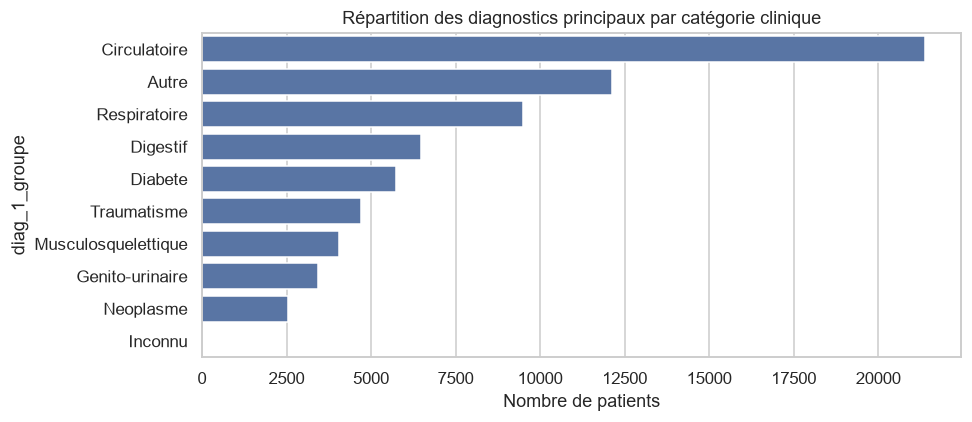

In [21]:
def grouper_icd9(code):
    """Regroupe un code ICD-9 en grande catégorie clinique."""
    if pd.isna(code) or code == 'Inconnu':
        return 'Inconnu'
    code = str(code)

    # Codes V (facteurs influençant l'état de santé) et E (causes externes)
    if code.startswith('V') or code.startswith('E'):
        return 'Autre'

    try:
        valeur = float(code)
    except ValueError:
        return 'Autre'

    if 390 <= valeur <= 459 or valeur == 785:
        return 'Circulatoire'
    elif 460 <= valeur <= 519 or valeur == 786:
        return 'Respiratoire'
    elif 520 <= valeur <= 579 or valeur == 787:
        return 'Digestif'
    elif 250 <= valeur < 251:
        return 'Diabete'
    elif 800 <= valeur <= 999:
        return 'Traumatisme'
    elif 710 <= valeur <= 739:
        return 'Musculosquelettique'
    elif 580 <= valeur <= 629 or valeur == 788:
        return 'Genito-urinaire'
    elif 140 <= valeur <= 239:
        return 'Neoplasme'
    else:
        return 'Autre'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_groupe'] = df[col].apply(grouper_icd9)

df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])

# Répartition du diagnostic principal
repartition = df['diag_1_groupe'].value_counts()
print(repartition)

plt.figure(figsize=(9, 4))
sns.barplot(x=repartition.values, y=repartition.index, color='#4C72B0')
plt.title('Répartition des diagnostics principaux par catégorie clinique')
plt.xlabel('Nombre de patients')
plt.tight_layout()
plt.show()

### 4.6 Indicateurs de sévérité et de parcours

In [22]:
# Admission via les urgences (facteur de risque documenté)
df['admission_urgences'] = (df['admission_source_id'].isin([7])).astype(int)

# Nombre de diagnostics = proxy de comorbidité (inspiré de l'index de Charlson)
df['comorbidite_elevee'] = (df['number_diagnoses'] >= 9).astype(int)

# Séjour long
df['sejour_long'] = (df['time_in_hospital'] >= 7).astype(int)

# Ratio intensité de soins / durée de séjour
df['intensite_soins'] = df['num_procedures'] / df['time_in_hospital'].clip(lower=1)

nouvelles = ['admission_urgences', 'comorbidite_elevee', 'sejour_long', 'intensite_soins']
df[nouvelles].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
admission_urgences,69987.0,0.533,0.499,0.0,0.0,1.000,1.000,1.0
comorbidite_elevee,69987.0,0.440,0.496,0.0,0.0,0.000,1.000,1.0
sejour_long,69987.0,0.195,0.396,0.0,0.0,0.000,0.000,1.0
intensite_soins,69987.0,0.498,0.920,0.0,0.0,0.182,0.571,6.0


### 4.7 Vérification du pouvoir discriminant des variables créées

Contrôle de cohérence : chaque variable créée doit montrer un écart de taux de
réadmission entre ses modalités. Une variable sans écart n'apportera rien au modèle.

In [23]:
variables_binaires = ['a_deja_ete_hospitalise', 'passage_urgences_anterieur',
                      'polymedication', 'admission_urgences',
                      'comorbidite_elevee', 'sejour_long']

resultats = []
for var in variables_binaires:
    taux_0 = df[df[var] == 0]['cible'].mean()
    taux_1 = df[df[var] == 1]['cible'].mean()
    resultats.append({
        'variable': var,
        'taux_si_0': f"{taux_0:.2%}",
        'taux_si_1': f"{taux_1:.2%}",
        'ecart_relatif': f"{(taux_1/taux_0 - 1)*100:+.1f}%"
    })

pd.DataFrame(resultats).sort_values('ecart_relatif', ascending=False)

,variable,taux_si_0,taux_si_1,ecart_relatif
0,a_deja_ete_hospitalise,8.13%,15.40%,+89.4%
3,admission_urgences,8.66%,9.26%,+7.0%
5,sejour_long,8.32%,11.69%,+40.4%
1,passage_urgences_anterieur,8.74%,12.02%,+37.5%
2,polymedication,7.90%,9.89%,+25.3%
4,comorbidite_elevee,8.14%,10.05%,+23.6%


---
## 5. Préparation finale des données

### 5.1 Encodage des variables catégorielles

On utilise un **one-hot encoding** pour les variables nominales : contrairement au
label encoding, il n'introduit pas de relation d'ordre artificielle entre modalités
(par exemple, il n'y a aucune raison que « Respiratoire » > « Circulatoire »).

In [24]:
# Séparation cible / variables explicatives
y = df['cible']
X = df.drop(columns=['cible', 'age'])   # 'age' remplacé par 'age_num'

# Identification des types
cols_categorielles = X.select_dtypes(include=['object']).columns.tolist()
cols_numeriques = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Variables catégorielles : {len(cols_categorielles)}")
print(f"Variables numériques    : {len(cols_numeriques)}")

# Les identifiants administratifs sont traités comme catégoriels
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    if col in cols_numeriques:
        X[col] = X[col].astype(str)
        cols_numeriques.remove(col)
        cols_categorielles.append(col)

print(f"\nAprès reclassement : {len(cols_categorielles)} catégorielles, {len(cols_numeriques)} numériques")

Variables catégorielles : 26
Variables numériques    : 22

Après reclassement : 29 catégorielles, 19 numériques


In [25]:
# One-hot encoding
X_encode = pd.get_dummies(X, columns=cols_categorielles, drop_first=True)

print(f"Dimensions après encodage : {X_encode.shape}")
print(f"Nombre de variables créées : {X_encode.shape[1] - len(cols_numeriques)}")

Dimensions après encodage : (69987, 214)
Nombre de variables créées : 195


### 5.2 Séparation train / test

Le split est **stratifié** : il conserve la proportion de la classe positive dans
les deux échantillons, ce qui est indispensable en contexte déséquilibré.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encode, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # essentiel en déséquilibre de classes
)

print(f"Entraînement : {X_train.shape[0]:,} patients — taux positif {y_train.mean():.2%}")
print(f"Test         : {X_test.shape[0]:,} patients — taux positif {y_test.mean():.2%}")

Entraînement : 55,989 patients — taux positif 8.98%
Test         : 13,998 patients — taux positif 8.98%


### 5.3 Standardisation

Nécessaire pour la régression logistique (sensible aux échelles).
Les modèles à base d'arbres (Random Forest, XGBoost) n'en ont pas besoin,
mais l'appliquer uniformément ne les pénalise pas.

**Point méthodologique important :** le `StandardScaler` est ajusté **uniquement**
sur le jeu d'entraînement, puis appliqué au jeu de test. L'ajuster sur l'ensemble
des données constituerait une fuite de données.

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit sur train uniquement
X_test_scaled = scaler.transform(X_test)         # transform seul sur test

print("Standardisation appliquée.")
print(f"Moyenne après standardisation (train) : {X_train_scaled.mean():.4f}")
print(f"Écart-type après standardisation (train) : {X_train_scaled.std():.4f}")

Standardisation appliquée.
Moyenne après standardisation (train) : 0.0000
Écart-type après standardisation (train) : 0.9977



## 6. Benchmark d'algorithmes

Trois familles d'algorithmes sont comparées, du plus interprétable au plus performant :

| Modèle | Nature | Intérêt |
|---|---|---|
| **Régression logistique** | Linéaire | Baseline de référence, coefficients directement interprétables |
| **Random Forest** | Ensemble d'arbres (bagging) | Capture les non-linéarités, robuste au surapprentissage |
| **XGBoost** | Ensemble d'arbres (boosting) | État de l'art sur données tabulaires |

### 6.1 Fonction d'évaluation commune

In [28]:
def evaluer_modele(nom, modele, X_tr, y_tr, X_te, y_te):
    """Entraîne un modèle et retourne ses métriques d'évaluation."""
    modele.fit(X_tr, y_tr)

    y_pred = modele.predict(X_te)
    y_proba = modele.predict_proba(X_te)[:, 1]

    resultats = {
        'Modèle': nom,
        'AUC-ROC': roc_auc_score(y_te, y_proba),
        'AP (PR-AUC)': average_precision_score(y_te, y_proba),
        'Précision': precision_score(y_te, y_pred, zero_division=0),
        'Rappel': recall_score(y_te, y_pred, zero_division=0),
        'F1-score': f1_score(y_te, y_pred, zero_division=0),
    }
    return resultats, modele, y_proba


resultats_benchmark = []
modeles_entraines = {}
probas = {}

print('Fonction d\'évaluation définie.')

Fonction d'évaluation définie.


### 6.2 Modèle 1 — Régression logistique (baseline)

In [29]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='liblinear'
)

res, mod, proba = evaluer_modele(
    'Régression logistique', log_reg,
    X_train_scaled, y_train, X_test_scaled, y_test
)
resultats_benchmark.append(res)
modeles_entraines['logreg'] = mod
probas['logreg'] = proba

pd.DataFrame([res]).round(4)

,Modèle,AUC-ROC,AP (PR-AUC),Précision,Rappel,F1-score
0,Régression logistique,0.6504,0.1727,0.3125,0.004,0.0079


> **Observation attendue :** le rappel sera très faible (proche de 0). C'est le
> symptôme classique du déséquilibre — le modèle prédit presque toujours la classe
> majoritaire. Ce constat justifie la section 6.5.

### 6.3 Modèle 2 — Random Forest

In [30]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

res, mod, proba = evaluer_modele(
    'Random Forest', rf,
    X_train, y_train, X_test, y_test    # pas besoin de standardisation
)
resultats_benchmark.append(res)
modeles_entraines['rf'] = mod
probas['rf'] = proba

pd.DataFrame([res]).round(4)

,Modèle,AUC-ROC,AP (PR-AUC),Précision,Rappel,F1-score
0,Random Forest,0.6539,0.18,0.0,0.0,0.0


### 6.4 Modèle 3 — XGBoost

In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

res, mod, proba = evaluer_modele(
    'XGBoost', xgb,
    X_train, y_train, X_test, y_test
)
resultats_benchmark.append(res)
modeles_entraines['xgb'] = mod
probas['xgb'] = proba

pd.DataFrame([res]).round(4)

,Modèle,AUC-ROC,AP (PR-AUC),Précision,Rappel,F1-score
0,XGBoost,0.6594,0.1854,0.4545,0.008,0.0156


### 6.5 Traitement du déséquilibre de classes

Deux stratégies sont comparées :

1. **Pondération des classes** (`scale_pos_weight` / `class_weight`) : le modèle
   pénalise davantage les erreurs sur la classe minoritaire. Aucune donnée créée.
2. **SMOTE** (*Synthetic Minority Over-sampling Technique*) : génération d'exemples
   synthétiques de la classe minoritaire par interpolation entre voisins proches.

**Précaution méthodologique majeure :** SMOTE ne doit être appliqué **que sur le jeu
d'entraînement**. L'appliquer avant le split créerait des exemples synthétiques
dérivés de patients du jeu de test — une fuite de données qui invaliderait les résultats.

In [32]:
# Stratégie 1 : pondération des classes
ratio_desequilibre = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio de déséquilibre : {ratio_desequilibre:.2f}")

xgb_pondere = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_desequilibre,   # <-- pondération
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

res, mod, proba = evaluer_modele(
    'XGBoost + pondération', xgb_pondere,
    X_train, y_train, X_test, y_test
)
resultats_benchmark.append(res)
modeles_entraines['xgb_pondere'] = mod
probas['xgb_pondere'] = proba

pd.DataFrame([res]).round(4)

Ratio de déséquilibre : 10.14


,Modèle,AUC-ROC,AP (PR-AUC),Précision,Rappel,F1-score
0,XGBoost + pondération,0.65,0.1788,0.1487,0.4893,0.2281


In [33]:
# Stratégie 2 : SMOTE (appliqué uniquement sur le jeu d'entraînement)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {X_train.shape[0]:,} observations — taux positif {y_train.mean():.2%}")
print(f"Après SMOTE : {X_train_smote.shape[0]:,} observations — taux positif {y_train_smote.mean():.2%}")

xgb_smote = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

res, mod, proba = evaluer_modele(
    'XGBoost + SMOTE', xgb_smote,
    X_train_smote, y_train_smote, X_test, y_test   # test reste intact
)
resultats_benchmark.append(res)
modeles_entraines['xgb_smote'] = mod
probas['xgb_smote'] = proba

pd.DataFrame([res]).round(4)

Avant SMOTE : 55,989 observations — taux positif 8.98%
Après SMOTE : 101,922 observations — taux positif 50.00%


,Modèle,AUC-ROC,AP (PR-AUC),Précision,Rappel,F1-score
0,XGBoost + SMOTE,0.636,0.1656,0.4167,0.0119,0.0232


### 6.6 Synthèse du benchmark

> **Deux précisions de lecture pour le mémoire :**
> 1. La « précision = 0,0000 » du Random Forest est en réalité **non définie** : le
>    modèle n'a émis *aucune* prédiction positive sur 13 998 patients (au seuil 0,5).
>    À présenter comme « n/a — aucune prédiction positive », ce qui renforce la
>    démonstration du piège de l'accuracy (~91 % d'accuracy pour un modèle inutile).
> 2. Précision, rappel et F1 sont mesurés au seuil arbitraire de 0,5 ; seules
>    l'AUC-ROC et l'AP comparent la capacité de *hiérarchisation* indépendamment
>    du seuil. Ratio de déséquilibre : 1:8 sur les séjours bruts, 1:10 dans la
>    cohorte de modélisation (d'où `scale_pos_weight` ≈ 10).

In [34]:
tableau_benchmark = pd.DataFrame(resultats_benchmark).round(4)
tableau_benchmark = tableau_benchmark.sort_values('AUC-ROC', ascending=False)
tableau_benchmark

,Modèle,AUC-ROC,AP (PR-AUC),Précision,Rappel,F1-score
2,XGBoost,0.6594,0.1854,0.4545,0.0080,0.0156
1,Random Forest,0.6539,0.1800,0.0000,0.0000,0.0000
0,Régression logistique,0.6504,0.1727,0.3125,0.0040,0.0079
3,XGBoost + pondération,0.6500,0.1788,0.1487,0.4893,0.2281
4,XGBoost + SMOTE,0.6360,0.1656,0.4167,0.0119,0.0232


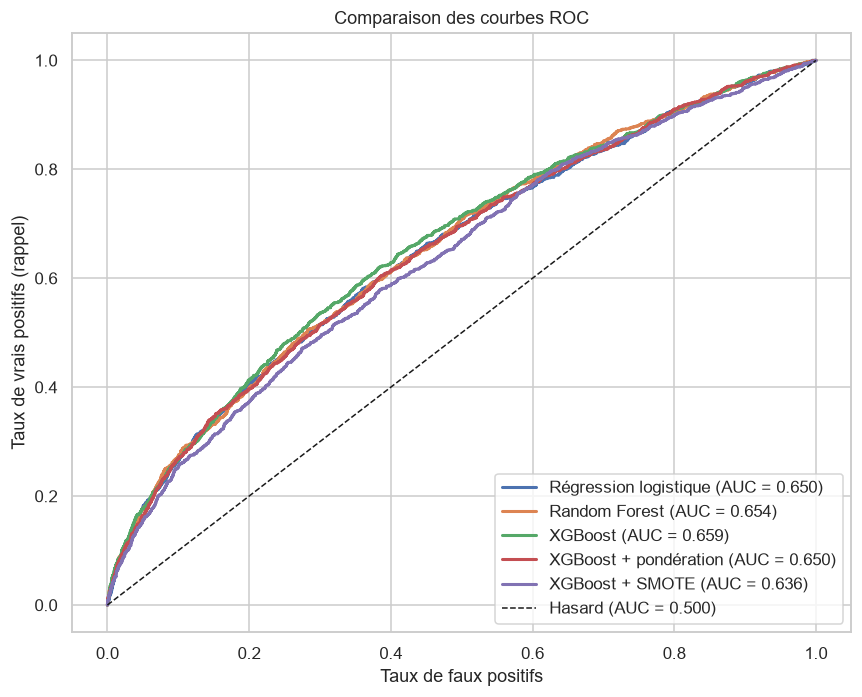

In [35]:
# Comparaison graphique des courbes ROC
plt.figure(figsize=(8, 6.5))

for cle, nom in [('logreg', 'Régression logistique'),
                 ('rf', 'Random Forest'),
                 ('xgb', 'XGBoost'),
                 ('xgb_pondere', 'XGBoost + pondération'),
                 ('xgb_smote', 'XGBoost + SMOTE')]:
    if cle in probas:
        fpr, tpr, _ = roc_curve(y_test, probas[cle])
        auc = roc_auc_score(y_test, probas[cle])
        plt.plot(fpr, tpr, label=f'{nom} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard (AUC = 0.500)')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs (rappel)')
plt.title('Comparaison des courbes ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

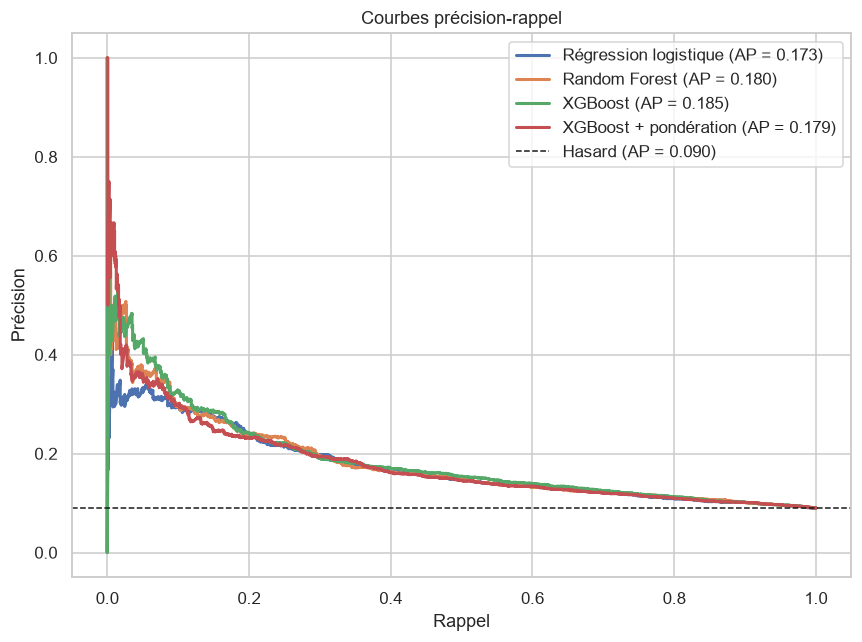

In [36]:
# Courbes précision-rappel — plus informatives que la ROC en déséquilibre
plt.figure(figsize=(8, 6))

for cle, nom in [('logreg', 'Régression logistique'),
                 ('rf', 'Random Forest'),
                 ('xgb', 'XGBoost'),
                 ('xgb_pondere', 'XGBoost + pondération')]:
    if cle in probas:
        prec, rap, _ = precision_recall_curve(y_test, probas[cle])
        ap = average_precision_score(y_test, probas[cle])
        plt.plot(rap, prec, label=f'{nom} (AP = {ap:.3f})', linewidth=2)

plt.axhline(y_test.mean(), color='k', linestyle='--', linewidth=1,
            label=f'Hasard (AP = {y_test.mean():.3f})')
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title('Courbes précision-rappel')
plt.legend()
plt.tight_layout()
plt.show()

> **Point d'analyse pour le mémoire.**
> La courbe précision-rappel est plus pertinente que la courbe ROC en contexte
> fortement déséquilibré : la ROC peut donner une impression flatteuse car le
> taux de faux positifs est calculé sur une classe négative très nombreuse.

### 6.7 Validation croisée du modèle retenu

Vérification que la performance n'est pas le fruit d'un découpage favorable.

In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_cv = cross_val_score(
    xgb_pondere, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f"AUC-ROC par fold : {np.round(scores_cv, 4)}")
print(f"AUC-ROC moyenne  : {scores_cv.mean():.4f} (± {scores_cv.std():.4f})")

AUC-ROC par fold : [0.64   0.636  0.6519 0.6498 0.6436]
AUC-ROC moyenne  : 0.6443 (± 0.0059)


### 6.8 Comparaison opérationnelle : XGBoost simple vs pondéré (lift à iso-capacité)

Le déploiement fonctionne par **classement** : on suit les k % de sortants les plus
risqués. Seule compte donc la capacité à *hiérarchiser* — que mesurent l'AUC et le lift,
pas le rappel au seuil 0,5. Or XGBoost simple a une meilleure AUC (0,6577) que sa
version pondérée (0,6477) : la pondération déplace l'échelle des scores sans améliorer
le classement (cf. enseignement n°2).

On compare donc les deux modèles sur le **lift à iso-capacité**, et on retient celui
qui maximise le lift moyen sur les capacités cibles (10-20 %). Argumentaire pour le
jury : *sélection sur métrique indépendante du seuil, puis calibrage explicite du
seuil selon la contrainte opérationnelle — la pondération devient redondante.*

In [38]:
# Comparaison du lift à iso-capacité entre xgb simple et xgb pondéré
capacites_cibles = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
comparaison_lift = []

for nom_modele in ['xgb', 'xgb_pondere']:
    proba = probas[nom_modele]
    for capacite in capacites_cibles:
        seuil = np.quantile(proba, 1 - capacite)
        pred = (proba >= seuil).astype(int)
        vp = ((pred == 1) & (y_test == 1)).sum()
        rappel = vp / (y_test == 1).sum()
        precision = vp / pred.sum()
        comparaison_lift.append({
            'Modèle': nom_modele,
            'Capacité': f"{capacite:.0%}",
            'Rappel': round(rappel, 4),
            'Précision': round(precision, 4),
            'Lift': round(precision / y_test.mean(), 2)
        })

df_comparaison_lift = pd.DataFrame(comparaison_lift)
tableau_pivot = df_comparaison_lift.pivot(index='Capacité', columns='Modèle', values='Lift')
tableau_pivot = tableau_pivot.reindex([f"{c:.0%}" for c in capacites_cibles])
print("LIFT PAR CAPACITÉ DE SUIVI")
print(tableau_pivot.to_string())

# Sélection automatique : meilleur lift moyen sur les capacités opérationnelles (10-20 %)
capa_operationnelles = ['10%', '15%', '20%']
lift_moyen = tableau_pivot.loc[capa_operationnelles].mean()
print(f"\nLift moyen (10-20 % de capacité) : "
      f"xgb = {lift_moyen.get('xgb', float('nan')):.3f} | "
      f"xgb_pondere = {lift_moyen.get('xgb_pondere', float('nan')):.3f}")

MODELE_RETENU = lift_moyen.idxmax()
# En cas de quasi-égalité (< 0.02 d'écart), on privilégie le modèle simple :
# scores mieux calibrés et argumentaire plus propre (pondération redondante).
if abs(lift_moyen.max() - lift_moyen.min()) < 0.02:
    MODELE_RETENU = 'xgb'

print(f"\n>>> MODÈLE RETENU : {MODELE_RETENU}")
df_comparaison_lift.to_csv('comparaison_lift_xgb_vs_pondere.csv', index=False)

LIFT PAR CAPACITÉ DE SUIVI
Modèle     xgb  xgb_pondere
Capacité                   
10%       2.46         2.44
15%       2.09         2.11
20%       1.92         1.90
25%       1.80         1.75
30%       1.70         1.64
40%       1.53         1.49

Lift moyen (10-20 % de capacité) : xgb = 2.157 | xgb_pondere = 2.150

>>> MODÈLE RETENU : xgb


---
## 7. Optimisation du seuil de décision

Un classifieur produit un **score**. Le seuil par défaut de 0,5 est un choix
arbitraire, rarement optimal en contexte déséquilibré et **jamais optimal en santé**,
où les erreurs ont des coûts asymétriques :

- **Faux négatif** : un patient à risque n'est pas suivi → réadmission évitable, coût élevé
- **Faux positif** : un patient sans risque est suivi inutilement → coût d'un appel infirmier

Le seuil doit donc être calibré selon deux contraintes :
1. Le rapport de coût entre les deux types d'erreur
2. **La capacité de suivi réellement disponible** dans l'établissement

> **Précaution méthodologique.** Le « seuil optimal F1 » calculé ci-dessous est
> **purement illustratif** : il est optimisé sur le jeu de test, ce qui en ferait un
> réglage contaminé s'il était retenu. L'approche effectivement retenue (§7.1) est le
> **seuil par capacité** : classer les sortants par score décroissant et suivre les
> k % les plus à risque — exactement le geste opérationnel en production, sans aucun
> réglage sur le test.

C'est un point de maturité fort à développer dans le mémoire.

In [39]:
# Le modèle retenu est déterminé par la comparaison de lift (section 6.8)
print(f"Modèle retenu (cf. §6.8) : {MODELE_RETENU}")
y_proba_final = probas[MODELE_RETENU]

# Balayage des seuils — ILLUSTRATIF uniquement (cf. avertissement ci-dessus)
seuils = np.arange(0.05, 0.95, 0.01)
lignes = []

for s in seuils:
    y_pred_s = (y_proba_final >= s).astype(int)
    lignes.append({
        'seuil': s,
        'precision': precision_score(y_test, y_pred_s, zero_division=0),
        'rappel': recall_score(y_test, y_pred_s, zero_division=0),
        'f1': f1_score(y_test, y_pred_s, zero_division=0),
        'nb_patients_cibles': y_pred_s.sum(),
        'pct_patients_cibles': y_pred_s.mean()
    })

df_seuils = pd.DataFrame(lignes)

# Seuil maximisant le F1 (illustration de l'arbitrage, non retenu)
seuil_optimal_f1 = df_seuils.loc[df_seuils['f1'].idxmax(), 'seuil']
print(f"Seuil maximisant le F1-score (illustratif) : {seuil_optimal_f1:.2f}")
df_seuils.loc[df_seuils['f1'].idxmax()].round(4)

Modèle retenu (cf. §6.8) : xgb
Seuil maximisant le F1-score (illustratif) : 0.11


seuil                     0.1100
precision                 0.1683
rappel                    0.4161
f1                        0.2397
nb_patients_cibles     3107.0000
pct_patients_cibles       0.2220
Name: 6, dtype: float64

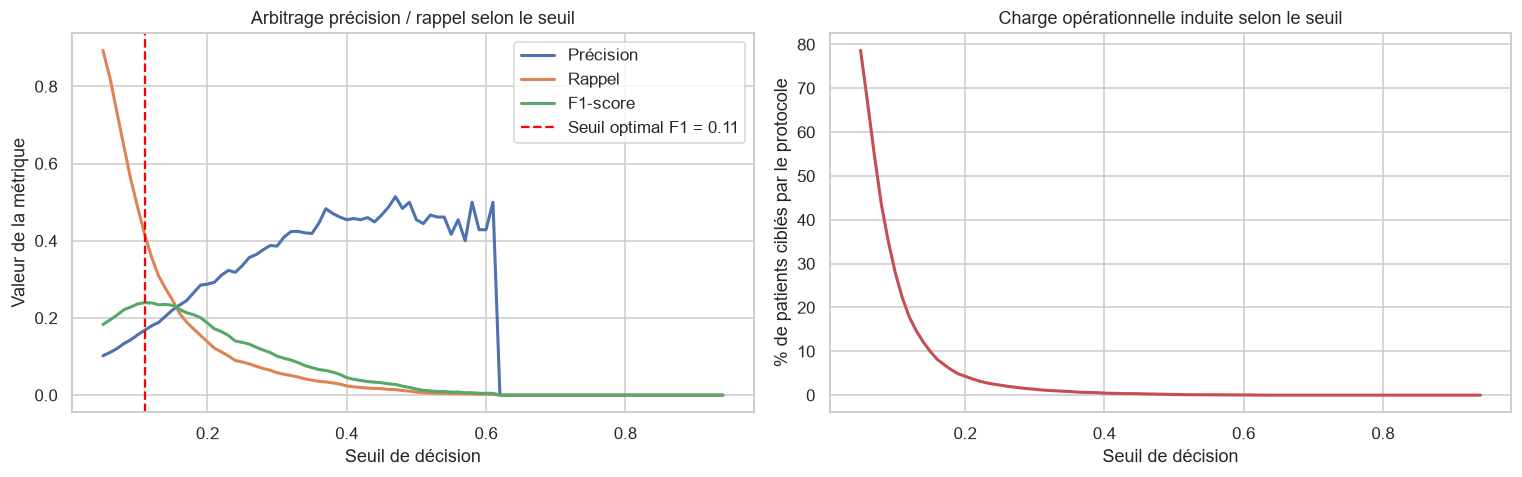

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Évolution des métriques selon le seuil
axes[0].plot(df_seuils['seuil'], df_seuils['precision'], label='Précision', linewidth=2)
axes[0].plot(df_seuils['seuil'], df_seuils['rappel'], label='Rappel', linewidth=2)
axes[0].plot(df_seuils['seuil'], df_seuils['f1'], label='F1-score', linewidth=2)
axes[0].axvline(seuil_optimal_f1, color='red', linestyle='--',
                label=f'Seuil optimal F1 = {seuil_optimal_f1:.2f}')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Valeur de la métrique')
axes[0].set_title('Arbitrage précision / rappel selon le seuil')
axes[0].legend()

# Volume de patients à prendre en charge
axes[1].plot(df_seuils['seuil'], df_seuils['pct_patients_cibles'] * 100,
             color='#C44E52', linewidth=2)
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel('% de patients ciblés par le protocole')
axes[1].set_title('Charge opérationnelle induite selon le seuil')

plt.tight_layout()
plt.show()

### 7.1 Scénarios opérationnels

On traduit ici le seuil en décision de gestion : combien de patients l'établissement
peut-il réellement suivre, et quelle proportion de réadmissions cela permet-il de détecter ?

Ce tableau est directement réutilisable dans la Partie 4 (analyse de rentabilité).

In [41]:
scenarios = []
for capacite in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    # Seuil correspondant à la capacité de suivi visée
    seuil = np.quantile(y_proba_final, 1 - capacite)
    y_pred_s = (y_proba_final >= seuil).astype(int)

    vp = ((y_pred_s == 1) & (y_test == 1)).sum()
    fp = ((y_pred_s == 1) & (y_test == 0)).sum()
    total_positifs = (y_test == 1).sum()

    scenarios.append({
        'Capacité de suivi': f"{capacite:.0%} des sortants",
        'Seuil': round(seuil, 3),
        'Patients suivis': y_pred_s.sum(),
        'Réadmissions détectées': vp,
        'Taux de détection (rappel)': f"{vp/total_positifs:.1%}",
        'Précision': f"{vp/(vp+fp):.1%}" if (vp+fp) > 0 else 'n/a',
        'Lift vs aléatoire': round((vp/y_pred_s.sum()) / y_test.mean(), 2)
    })

df_scenarios = pd.DataFrame(scenarios)
df_scenarios

,Capacité de suivi,Seuil,Patients suivis,Réadmissions détectées,Taux de détection (rappel),Précision,Lift vs aléatoire
0,10% des sortants,0.150,1400,309,24.6%,22.1%,2.46
1,15% des sortants,0.129,2100,395,31.4%,18.8%,2.09
2,20% des sortants,0.115,2800,482,38.3%,17.2%,1.92
3,25% des sortants,0.105,3500,567,45.1%,16.2%,1.80
4,30% des sortants,0.097,4200,640,50.9%,15.2%,1.70
5,40% des sortants,0.084,5599,770,61.3%,13.8%,1.53


> **Lecture clé :** le *lift* indique combien de fois le ciblage par le modèle est
> plus efficace qu'un ciblage aléatoire. Un lift de 2 signifie que le protocole
> capte deux fois plus de futurs réadmis à effort constant. **C'est cette métrique
> qui fonde le calcul de rentabilité de la Partie 4.**

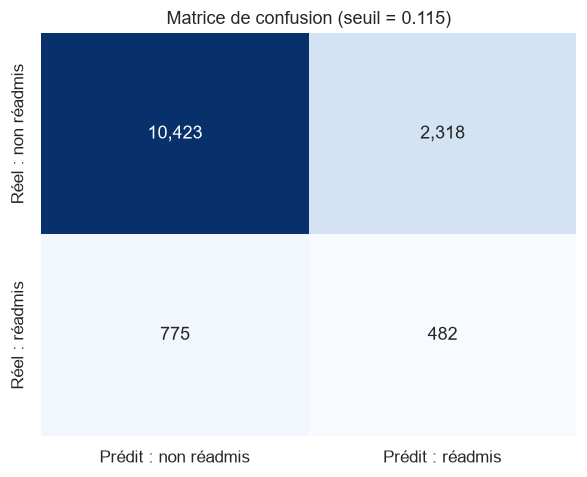

               precision    recall  f1-score   support

  Non réadmis       0.93      0.82      0.87     12741
Réadmis < 30j       0.17      0.38      0.24      1257

     accuracy                           0.78     13998
    macro avg       0.55      0.60      0.55     13998
 weighted avg       0.86      0.78      0.81     13998



In [42]:
# Matrice de confusion au seuil retenu
SEUIL_RETENU = float(np.quantile(y_proba_final, 1 - 0.20))   # cibler 20 % des sortants
y_pred_final = (y_proba_final >= SEUIL_RETENU).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Prédit : non réadmis', 'Prédit : réadmis'],
            yticklabels=['Réel : non réadmis', 'Réel : réadmis'])
plt.title(f'Matrice de confusion (seuil = {SEUIL_RETENU:.3f})')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_final,
                            target_names=['Non réadmis', 'Réadmis < 30j']))

---
## 8. Interprétabilité par SHAP

Un modèle non explicable ne sera pas adopté par les équipes soignantes — et
l'explicabilité est par ailleurs une exigence du RGPD (article 22) et de l'AI Act
européen pour les systèmes à haut risque, catégorie dont relève la santé.

**SHAP** (*SHapley Additive exPlanations*) repose sur les valeurs de Shapley issues
de la théorie des jeux : chaque variable est traitée comme un « joueur » et sa
contribution à la prédiction est calculée équitablement.

In [43]:
import shap

modele_final = modeles_entraines[MODELE_RETENU]

# TreeExplainer : optimisé pour les modèles à base d'arbres
explainer = shap.TreeExplainer(modele_final)

# Calcul sur un échantillon pour limiter le temps de calcul
TAILLE_ECHANTILLON = 2000
X_shap = X_test.sample(n=min(TAILLE_ECHANTILLON, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

print(f"Valeurs SHAP calculées sur {X_shap.shape[0]:,} patients.")

Valeurs SHAP calculées sur 2,000 patients.


### 8.1 Interprétation globale — quels facteurs pilotent le risque ?

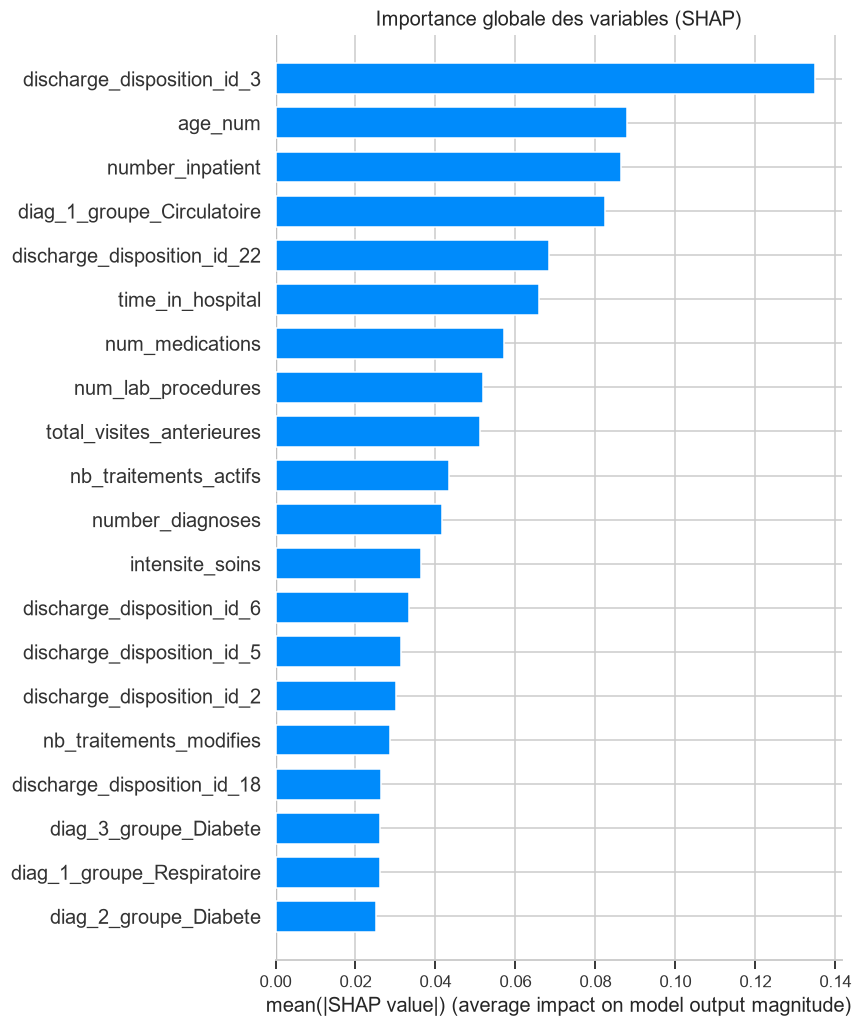

In [44]:
# Importance globale (moyenne des valeurs absolues)
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('Importance globale des variables (SHAP)', fontsize=13)
plt.tight_layout()
plt.show()

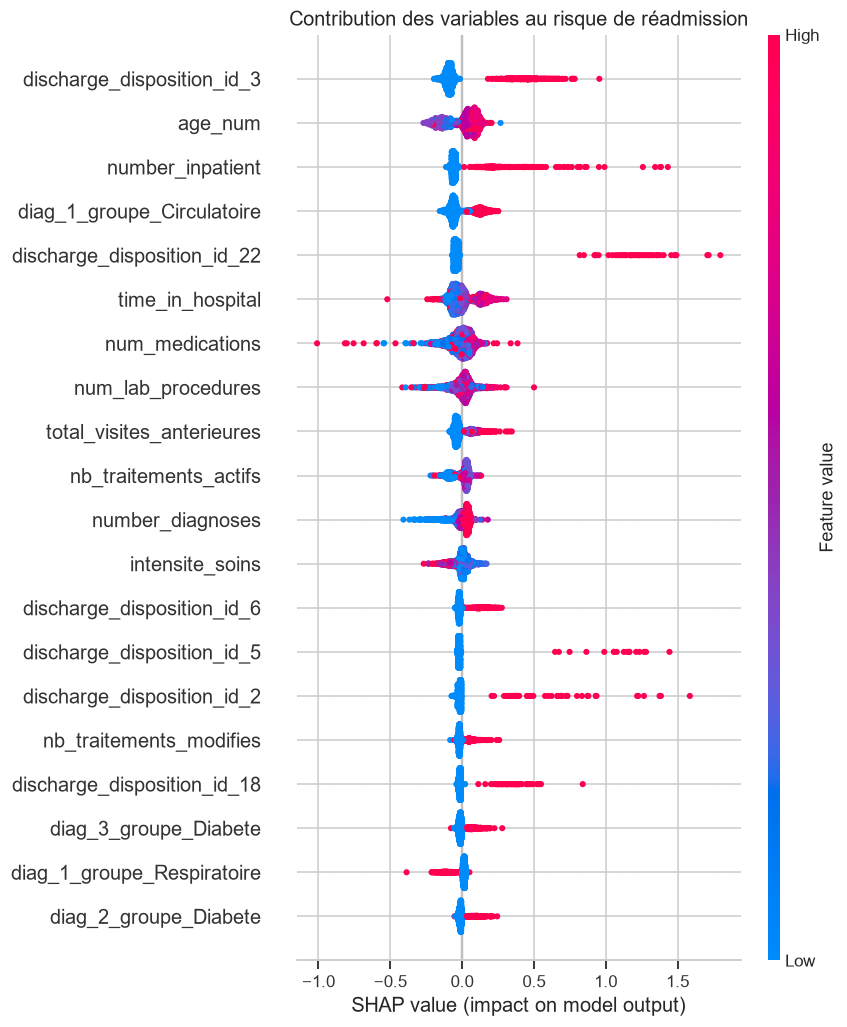

In [45]:
# Summary plot détaillé : sens et amplitude de l'effet
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('Contribution des variables au risque de réadmission', fontsize=13)
plt.tight_layout()
plt.show()

> **Lecture du summary plot :**
> - Chaque point représente un patient
> - Position horizontale = contribution au risque (droite = augmente le risque)
> - Couleur = valeur de la variable (rouge = valeur élevée, bleu = valeur faible)
>
> Exemple d'interprétation attendue : si `number_inpatient` apparaît en haut avec
> des points rouges à droite, cela signifie qu'un nombre élevé d'hospitalisations
> antérieures augmente fortement le risque — cohérent avec la littérature.

### 8.2 Interprétation locale — expliquer un patient précis

C'est cette visualisation qui sera présentée au médecin ou à l'infirmier
de coordination : elle justifie pourquoi ce patient est signalé.

Score de risque de ce patient : 0.611 (patient le plus à risque de l'échantillon de 2,000)


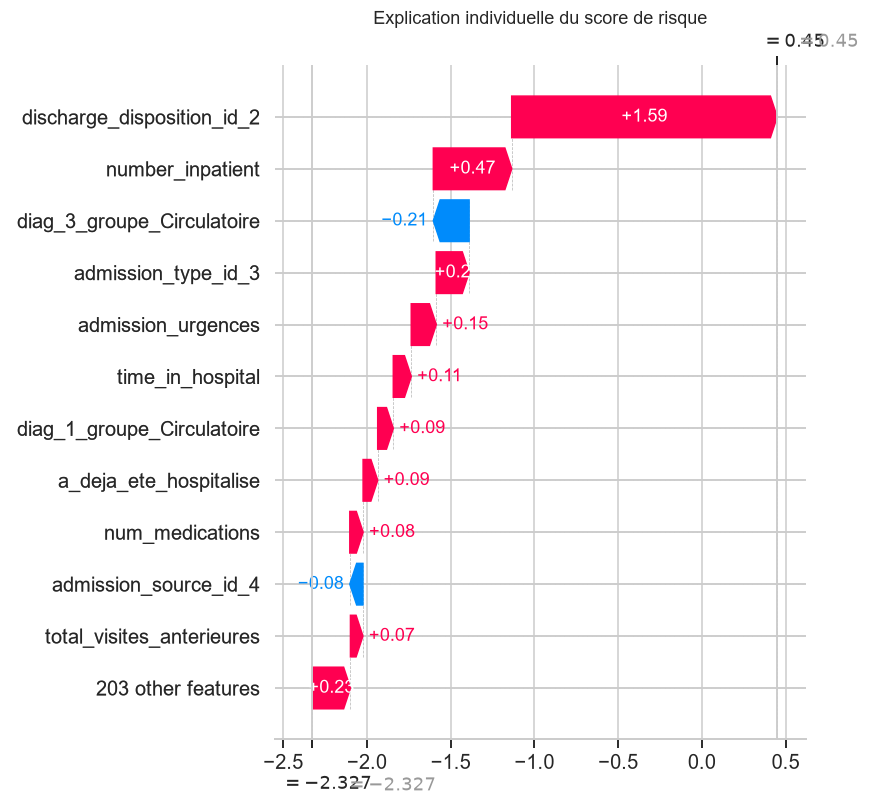

In [46]:
# Sélection d'un patient à haut risque
indices_haut_risque = np.argsort(-modele_final.predict_proba(X_shap)[:, 1])[:5]
idx_patient = indices_haut_risque[0]

score_patient = modele_final.predict_proba(X_shap.iloc[[idx_patient]])[0, 1]
# NB : on parle de SCORE DE RISQUE, pas de probabilité — les sorties d'un modèle
# pondéré ne sont pas calibrées (échelle gonflée par scale_pos_weight). Le score
# sert à CLASSER les patients ; ne jamais l'afficher comme « probabilité » aux équipes.
print(f"Score de risque de ce patient : {score_patient:.3f} "
      f"(patient le plus à risque de l'échantillon de {len(X_shap):,})")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx_patient],
    X_shap.iloc[idx_patient],
    max_display=12,
    show=False
)
plt.title('Explication individuelle du score de risque', fontsize=12)
plt.tight_layout()
plt.show()

### 8.3 Traduction clinique des facteurs de risque

Tableau à reprendre dans la Partie 3 du mémoire pour relier le modèle
au protocole d'intervention.

In [47]:
# Table de correspondance des identifiants administratifs (source : IDS_mapping.csv
# du dataset UCI — libellés traduits ; à vérifier contre le fichier original)
LIBELLES_SORTIE = {
    '1': 'Retour à domicile',
    '2': 'Transfert vers un autre hôpital de court séjour',
    '3': 'Transfert en établissement de soins infirmiers (SNF)',
    '4': 'Transfert en établissement de soins intermédiaires (ICF)',
    '5': 'Transfert vers un autre établissement de soins',
    '6': "Retour à domicile avec service de soins à domicile",
    '7': 'Sortie contre avis médical',
    '8': "Domicile avec perfusion à domicile",
    '22': "Transfert vers un établissement de réadaptation",
    '23': 'Transfert en hôpital de long séjour',
    '24': 'Transfert en maison de soins (Medicaid)',
    '25': 'Non renseigné',
}
LIBELLES_ADMISSION_SOURCE = {
    '1': 'Adressage par un médecin', '2': "Adressage par une clinique",
    '4': "Transfert d'un hôpital", '5': "Transfert d'un SNF",
    '6': "Transfert d'un autre établissement", '7': 'Admission via les urgences',
    '9': 'Non disponible', '17': 'Non renseigné', '20': 'Non renseigné',
}
LIBELLES_ADMISSION_TYPE = {
    '1': 'Urgence', '2': 'Urgent', '3': 'Programmée', '4': 'Nouveau-né',
    '5': 'Non disponible', '6': 'Non renseigné', '8': 'Non renseigné',
}

def rendre_lisible(nom_variable):
    """Traduit un nom de variable one-hot en libellé clinique lisible."""
    for prefixe, table, etiquette in [
        ('discharge_disposition_id_', LIBELLES_SORTIE, 'Sortie'),
        ('admission_source_id_', LIBELLES_ADMISSION_SOURCE, 'Admission'),
        ('admission_type_id_', LIBELLES_ADMISSION_TYPE, "Type d'admission"),
    ]:
        if nom_variable.startswith(prefixe):
            code_id = nom_variable[len(prefixe):]
            return f"{etiquette} : {table.get(code_id, 'code ' + code_id)}"
    return nom_variable

importance = pd.DataFrame({
    'variable': X_shap.columns,
    'importance_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('importance_shap', ascending=False).head(15)

importance['importance_relative'] = (
    importance['importance_shap'] / importance['importance_shap'].sum() * 100
).round(1)
importance['libelle_clinique'] = importance['variable'].apply(rendre_lisible)

importance.reset_index(drop=True)[['libelle_clinique', 'variable',
                                   'importance_shap', 'importance_relative']]

,libelle_clinique,variable,importance_shap,importance_relative
0,Sortie : Transfert en établissement de soins i...,discharge_disposition_id_3,0.134847,15.0
1,age_num,age_num,0.087895,9.7
2,number_inpatient,number_inpatient,0.086322,9.6
3,diag_1_groupe_Circulatoire,diag_1_groupe_Circulatoire,0.082318,9.1
4,Sortie : Transfert vers un établissement de ré...,discharge_disposition_id_22,0.068358,7.6
5,time_in_hospital,time_in_hospital,0.065816,7.3
6,num_medications,num_medications,0.057020,6.3
7,num_lab_procedures,num_lab_procedures,0.051867,5.8
8,total_visites_anterieures,total_visites_anterieures,0.051060,5.7
9,nb_traitements_actifs,nb_traitements_actifs,0.043372,4.8


### 8.4 Analyse d'équité par sous-groupe

Un modèle qui sous-détecterait le risque sur un sous-groupe (origine, genre) créerait
une **inégalité d'accès au dispositif de suivi** — enjeu éthique et exigence directe
de l'AI Act pour les systèmes à haut risque. On mesure ici l'AUC par sous-groupe :
des AUC homogènes indiquent que le modèle hiérarchise aussi bien dans chaque groupe.

In [48]:
# AUC par sous-groupe démographique (sur le jeu de test)
lignes_equite = []

for variable_groupe in ['race', 'gender']:
    groupes_test = df.loc[X_test.index, variable_groupe]
    for modalite in sorted(groupes_test.unique()):
        masque = (groupes_test == modalite).values
        n = int(masque.sum())
        n_pos = int(y_test[masque].sum())
        # Effectifs minimaux pour une AUC stable
        if n >= 200 and n_pos >= 20:
            auc_g = roc_auc_score(y_test[masque], y_proba_final[masque])
            taux_g = y_test[masque].mean()
            lignes_equite.append({
                'Variable': variable_groupe, 'Sous-groupe': modalite,
                'Effectif test': n, 'Positifs': n_pos,
                'Taux réadmission': f"{taux_g:.2%}", 'AUC-ROC': round(auc_g, 3)
            })
        else:
            lignes_equite.append({
                'Variable': variable_groupe, 'Sous-groupe': modalite,
                'Effectif test': n, 'Positifs': n_pos,
                'Taux réadmission': f"{y_test[masque].mean():.2%}" if n > 0 else 'n/a',
                'AUC-ROC': 'n/a (effectif insuffisant)'
            })

df_equite = pd.DataFrame(lignes_equite)
df_equite.to_csv('equite_sous_groupes.csv', index=False)
df_equite

,Variable,Sous-groupe,Effectif test,Positifs,Taux réadmission,AUC-ROC
0,race,AfricanAmerican,2504,231,9.23%,0.68
1,race,Asian,96,9,9.38%,n/a (effectif insuffisant)
2,race,Caucasian,10522,954,9.07%,0.65
3,race,Hispanic,286,30,10.49%,0.675
4,race,Inconnu,361,22,6.09%,0.689
5,race,Other,229,11,4.80%,n/a (effectif insuffisant)
6,gender,Female,7507,664,8.85%,0.663
7,gender,Male,6491,593,9.14%,0.655


> **Lecture pour le mémoire :** comparer les AUC entre sous-groupes. Un écart
> inférieur à ~0,03 est généralement considéré comme homogène compte tenu de la
> variance d'échantillonnage. Si un sous-groupe présente une AUC nettement plus
> faible, le documenter en limite (§2.8 du mémoire) et prévoir un monitoring
> d'équité dans le plan de déploiement (Partie 3.6).

---
## 9. Synthèse et export des résultats

### 9.1 Tableau de synthèse du benchmark

In [49]:
print("=" * 70)
print("SYNTHÈSE DU BENCHMARK D'ALGORITHMES")
print("=" * 70)
print(tableau_benchmark.to_string(index=False))
print()
print(f"Modèle retenu : {MODELE_RETENU}")
print(f"Seuil de décision retenu : {SEUIL_RETENU:.3f}")
print(f"Cohorte finale : {len(df):,} patients")
print(f"Taux de réadmission observé : {y.mean():.2%}")
print("=" * 70)

SYNTHÈSE DU BENCHMARK D'ALGORITHMES
               Modèle  AUC-ROC  AP (PR-AUC)  Précision  Rappel  F1-score
              XGBoost   0.6594       0.1854     0.4545  0.0080    0.0156
        Random Forest   0.6539       0.1800     0.0000  0.0000    0.0000
Régression logistique   0.6504       0.1727     0.3125  0.0040    0.0079
XGBoost + pondération   0.6500       0.1788     0.1487  0.4893    0.2281
      XGBoost + SMOTE   0.6360       0.1656     0.4167  0.0119    0.0232

Modèle retenu : xgb
Seuil de décision retenu : 0.115
Cohorte finale : 69,987 patients
Taux de réadmission observé : 8.98%


### 9.2 Export pour le mémoire

In [ ]:
# Export des tableaux au format CSV (réutilisables dans le mémoire)
tableau_benchmark.to_csv('resultats_benchmark.csv', index=False)
df_scenarios.to_csv('scenarios_operationnels.csv', index=False)
importance.to_csv('importance_variables_shap.csv', index=False)
df_comparaison_lift.to_csv('comparaison_lift_xgb_vs_pondere.csv', index=False)
df_equite.to_csv('equite_sous_groupes.csv', index=False)

print("Fichiers exportés :")
print("  - resultats_benchmark.csv")
print("  - scenarios_operationnels.csv")
print("  - importance_variables_shap.csv")
print("  - comparaison_lift_xgb_vs_pondere.csv")
print("  - equite_sous_groupes.csv")

Fichiers exportés :
  - resultats_benchmark.csv
  - scenarios_operationnels.csv
  - importance_variables_shap.csv
  - comparaison_lift_xgb_vs_pondere.csv
  - equite_sous_groupes.csv


: 

---

## 10. Points d'analyse à développer dans le mémoire

### 10.1 Sur la performance

La littérature obtient sur ce dataset des AUC de l'ordre de **0,63 à 0,68**.
Ce résultat modeste doit être **analysé, pas masqué**. Pistes d'explication :

- La réadmission dépend largement de facteurs **absents du dataset** : conditions
  sociales, isolement, observance thérapeutique, qualité du suivi en ville
- Les données sont anciennes (1999-2008) et limitées à une population diabétique
- Une part des réadmissions est **intrinsèquement imprévisible** (aléas cliniques)

**Argument à défendre devant le jury :** même un modèle à AUC 0,65 crée de la valeur
dès lors qu'il permet de **cibler** l'effort de suivi. Le lift calculé en section 7.1
est la preuve chiffrée de cette valeur — c'est lui, et non l'AUC, qui fonde le ROI.

### 10.2 Sur la transposabilité au contexte français

Différences à discuter honnêtement :
- Système de santé américain (assurantiel) vs français (universel)
- Codification ICD-9 vs CIM-10 / PMSI en France
- Population restreinte aux patients diabétiques
- Ancienneté des données

→ Positionner le travail comme une **validation méthodologique** transposable,
et non comme un modèle directement déployable en l'état.

### 10.3 Sur les biais et l'équité algorithmique

- Vérifier que le modèle ne discrimine pas selon l'origine ethnique (`race`) ou le genre
- Un modèle qui sous-détecte le risque sur un sous-groupe créerait une inégalité d'accès
  au dispositif de suivi
- Enjeu directement lié aux obligations de l'AI Act

### 10.4 Analyse d'équité — IMPLÉMENTÉE en section 8.4

L'analyse est désormais exécutée en §8.4 (AUC par sous-groupe `race` et `gender`, export `equite_sous_groupes.csv`). Reporter le tableau dans la Partie 2.8 du mémoire et commenter l'homogénéité des AUC.
